# モーターpt 改善検証 — 「おかぺんモーター評価」を正解にした多変数 順位相関分析

**目的**: 強さポイントの一成分 **モーターpt** を、ドメインエキスパートのモーター評価に
近づけられないかを検証する。正解(ground truth)には、ボートレース平和島が公開する
**「おかぺんモーター評価」**(機番ごとの `SS〜E` グレード)を用いる。
<https://www.heiwajima.gr.jp/01motor/motor_assessment.htm>

**このノートブックでやること**
1. 現状調査 — 現行モーターptがどう計算され、どの情報を使い・使っていないかを整理
2. 正解データ — おかぺん評価(平和島 1 場・1 スナップショット, 40 機)を取り込み数値化
3. データ結合 — 機番をキーに、**複数ソースから多数の説明変数候補** を集計して束ねる
   (race_cards の公式連対率 / previews の展示タイム・周回足など / motor_stats の成績)
4. **多変数の順位相関スキャン** — 各候補とおかぺん評価の Spearman / Kendall を一覧化し、
   **モーターptの組成に使える説明変数の候補を洗い出す**
5. 改善仮説の検証 — 有望候補を合成したスコアの順位相関を比較
6. 結論 — 採用候補の優先順位と、その限界・次の一手

**前提・スコープ・制約**(重要)
- 成果指標は **おかぺん評価との順位相関**(ユーザー指定)。回収率は今回の主軸ではない。
- おかぺん評価の過去スナップショットは保存されておらず、取得できる正解は
  **平和島 1 場・現スナップショット(40 機)** のみ。まずこの 1 断面で **手法を確立** する。
- 各候補には **カバレッジ(n)** と **取得タイミング(朝daily / 直前realtime)** を併記する。
  朝バッチ時点のモーターptに使えるのは daily 系のみ。展示・周回足など preview 由来は
  直前(realtime)でしか使えない点に注意。
- サンプルは n≤40(単一場・単一節)。本検証は **方向性の探索** であり、確定的結論や
  本番コード変更は行わない(成果物は本ノートのみ)。


## 0. セットアップ

In [1]:
%matplotlib inline
import sys, io, math
from pathlib import Path
from itertools import product
from collections import defaultdict
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, kendalltau
from sklearn.linear_model import LinearRegression

import matplotlib
import matplotlib.pyplot as plt
# 図のラベルは日本語フォント非依存にするため英字(romaji)で書く。
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 80)

def find_repo_root(start: Path) -> Path:
    for cand in [start.resolve(), *start.resolve().parents]:
        if (cand / "data" / "estimate").exists() and (cand / "scripts").exists():
            return cand
    raise RuntimeError("repo root (with data/estimate and scripts) not found")

REPO_ROOT = find_repo_root(Path.cwd())
STADIUM = "04"   # 平和島
SESSION_DATES = ["2026-05-12", "2026-05-13", "2026-05-14", "2026-05-15", "2026-05-16"]
print("REPO_ROOT =", REPO_ROOT)
print("対象場 =", STADIUM, "(平和島) / 節 =", SESSION_DATES[0], "〜", SESSION_DATES[-1])

REPO_ROOT = /sessions/exciting-modest-lamport/mnt/boatracecsv.github.io
対象場 = 04 (平和島) / 節 = 2026-05-12 〜 2026-05-16


## 1. 現状調査 — 現行モーターptの算出ロジック

モーターptは `scripts/boatrace/index_features.py` の **モーター能力指数 v2** で計算される
(設計書: `docs/design/motor_ability_index_v2.md`)。流れは次のとおり。

1. **着順スコア表**(`data/estimate/motor_ability_score.csv`)— 直近走の **着順** を
   「級別 × グレード分類 × 着順」で得点化(1着が高い)。事故(転覆/落水/沈没/エンスト)は -100。
2. **コース補正(z 残差)** — `(級別, グレード, コース)` セルの平均・SD で `(raw − μ)/σ` に標準化。
3. **時間減衰** — `exp(-ln2 × 経過日数 / 60)`(半減期 60 日)で直近走を重く。
4. **ベイズ収縮** — `n_eff/(n_eff+10)` 倍。**履歴が無いモーターは NaN → 下流で 50 補完**。
5. `build_index.py` が **場別に偏差値化**(平均 50・SD 10)→ CSV の `N枠_モーターpt`。

要するに **現モーターpt は「直近走の着順」だけを入力** にした指標。**値が大きいほど良い**。
着順履歴が乏しいモーターは **中立値 50 にフォールバック** する。

In [2]:
score_tbl = pd.read_csv(REPO_ROOT / "data/estimate/motor_ability_score.csv")
print("data/estimate/motor_ability_score.csv:")
display(score_tbl)
try:
    sys.path.insert(0, str(REPO_ROOT / "scripts"))
    from boatrace import index_features as ifeat
    print("\n現行フラグ/定数 (index_features.py):")
    for k in ["ENABLE_DECAY", "ENABLE_LANE_CORRECTION", "ENABLE_SHRINKAGE",
              "DECAY_HALF_LIFE_DAYS", "SHRINKAGE_PRIOR_K", "MOTOR_HISTORY_SESSIONS"]:
        print(f"  {k} = {getattr(ifeat, k)}")
except Exception as e:
    print("\n[note] index_features の import をスキップ:", e)

data/estimate/motor_ability_score.csv:


,級別,グレード分類,1着pt,2着pt,3着pt,4着pt,5着pt,6着pt
0,B2,全,125,100,75,50,25,0
1,B1,全,100,80,60,40,20,0
2,A2,SG_G1,125,100,75,50,25,0
3,A2,G2_G3_一般,75,60,45,30,15,0
4,A1,SG_G1,100,80,60,40,20,0
5,A1,G2_G3_一般,50,40,30,20,10,0



現行フラグ/定数 (index_features.py):
  ENABLE_DECAY = True
  ENABLE_LANE_CORRECTION = True
  ENABLE_SHRINKAGE = True
  DECAY_HALF_LIFE_DAYS = 60.0
  SHRINKAGE_PRIOR_K = 10.0
  MOTOR_HISTORY_SESSIONS = 6


現モーターptは着順しか見ていない。一方おかぺん評価は **2連率・前検タイム・出足/伸び**
(=速さ)を強く参照する。そこで §3〜§4 では、リポジトリにある **モーター由来の数値を可能な
限り集めて** おかぺん評価との順位相関を測り、モーターptに足せる説明変数の候補を洗い出す。

## 2. 正解データ — 平和島「おかぺんモーター評価」

平和島公式サイトのスナップショット(`◆2連率集計 2025/6/9〜2026/5/8 ／更新 2026/5/11`、
2026-05-12 開催節の前検評価)を埋め込む。

In [3]:
OKAPEN_CSV = """順位,機番,2連率,前検タイム,優出,優勝,評価,出足,伸び
1,60,48.3,7.14,8,1,A+,◎,◎
2,34,47.5,7.02,9,3,A+,◉,◎
3,55,45.4,7.14,9,2,B+,▲,○
4,44,44.7,7.17,5,0,SS,◎,◉
5,54,43.5,7.22,6,1,A+,◎,◉
6,25,43.3,7.06,6,3,SS,◎,◎
7,41,40.9,7.18,4,1,A-,○,◎
8,43,39.0,7.12,6,1,A,◎,◎
9,68,38.9,7.07,5,0,A+,◎,◎
10,17,38.8,7.09,6,1,A,○,◎
11,29,38.5,7.17,2,1,A,◎,◎
12,27,37.6,7.15,5,1,A,○,◎
13,14,37.2,7.08,4,0,B+,○,○
14,73,37.0,7.10,3,1,B,○,○
15,72,36.9,7.09,6,1,S,◉,○
16,19,36.6,7.22,3,0,D,○,△
17,36,36.0,7.13,5,2,A+,◎,◉
18,37,35.8,7.10,2,1,C,△,△
19,66,35.3,7.26,4,0,B,▲,△
20,56,35.1,7.06,4,2,A,◎,◎
21,71,34.8,7.15,5,1,A-,○,○
22,22,34.2,7.07,4,1,B+,○,○
22,24,34.2,7.15,1,0,A-,○,○
24,45,33.7,7.09,3,1,B+,○,○
25,59,33.4,7.23,1,0,B+,○,○
26,33,32.9,7.25,2,0,S,◎,◉
27,23,32.8,7.08,3,0,C,▲,▲
28,38,32.6,7.14,2,0,A-,◎,◎
29,49,32.3,7.28,4,0,B+,◎,▲
30,40,32.1,7.13,3,0,A,◎,○
31,47,31.9,7.06,1,0,B+,○,○
32,75,31.6,7.22,3,1,C,▲,▲
33,62,31.5,7.16,2,1,A-,○,◎
34,63,31.3,7.12,2,0,B,▲,▲
35,58,30.9,7.06,1,0,E,×,△
36,10,30.7,7.23,1,0,B+,△,△
37,20,30.1,7.17,2,0,B+,△,△
37,46,30.1,7.18,1,1,C,▲,△
39,61,29.8,7.00,4,0,B,▲,▲
40,39,29.5,7.10,1,0,B-,○,○
"""
okapen = pd.read_csv(io.StringIO(OKAPEN_CSV))
GRADE_NUM = {"SS":11,"S":10,"A+":9,"A":8,"A-":7,"B+":6,"B":5,"B-":4,"C":3,"D":2,"E":1}
MARK_NUM  = {"◉":5,"◎":4,"○":3,"▲":2,"△":1,"×":0}
okapen["評価num"] = okapen["評価"].map(GRADE_NUM)
okapen["出足num"] = okapen["出足"].map(MARK_NUM)
okapen["伸びnum"] = okapen["伸び"].map(MARK_NUM)
okapen["機番"] = okapen["機番"].astype(int)
print("おかぺん評価:", okapen.shape[0], "機 / グレード分布:")
print(okapen["評価"].value_counts().reindex(list(GRADE_NUM)).dropna().astype(int).to_string())
display(okapen.head(6))

おかぺん評価: 40 機 / グレード分布:
評価
SS    2
S     2
A+    5
A     6
A-    5
B+    9
B     4
B-    1
C     4
D     1
E     1


,順位,機番,2連率,前検タイム,優出,優勝,評価,出足,伸び,評価num,出足num,伸びnum
0,1,60,48.3,7.14,8,1,A+,◎,◎,9,4,4
1,2,34,47.5,7.02,9,3,A+,◉,◎,9,5,4
2,3,55,45.4,7.14,9,2,B+,▲,○,6,2,3
3,4,44,44.7,7.17,5,0,SS,◎,◉,11,4,5
4,5,54,43.5,7.22,6,1,A+,◎,◉,9,4,5
5,6,25,43.3,7.06,6,3,SS,◎,◎,11,4,4


> **他場スコープ**: 公式調査の結果、`SS〜E` の統一グレード評価は平和島(おかぺん)固有で、
> 他場は数値ランキング止まり。横断比較できる正解の追加は困難なため、平和島で手法を確立する
> (将来、別場のグレードを入手でき次第、同じ「機番→評価num」形式で差し込める)。

## 3. データ結合 — 機番をキーに「多数の説明変数候補」を集める

モーター由来の数値を、複数ソースから機番ごとに節平均で集計する。

| ソース | 変数 | 取得 | 向き | カバレッジ |
| --- | --- | --- | --- | --- |
| `race_cards` | 公式モーター2連対率 / 3連対率 | 朝(daily) | 大きいほど良 | 全 40 機 |
| `race_cards` | (参考)選手 全国勝率 | 朝(daily) | 大きいほど良 | 全 40 機 |
| `estimate/v1_basic` | 現モーターpt(偏差値)+ 中立50率 | 朝(daily) | 大きいほど良 | 全 40 機 |
| `previews/tkz` | 展示タイム | 直前(realtime) | **小さいほど良(反転)** | 全 40 機 |
| `previews/original_exhibition` | 一周 / まわり足 / 直線(平和島の計測項目) | 直前(realtime) | **小さいほど良(反転)** | 全 40 機 |
| `programs/motor_stats` | 勝率 / 平均ラップ秒 / 優勝・優出回数 / 1着率 / 整備回数 ほか | 朝(daily) | 変数による | **26 機のみ**(機番55〜75 欠落) |

> `motor_stats` は本節の平和島分が機番 55〜75 を欠くため n=26。`race_cards`/`previews` は
> 全 40 機を整合的に覆う。時間系(展示タイム・一周・まわり足・直線・平均ラップ)は
> 「小さいほど速い=良い」ので相関時に符号反転する。

In [4]:
def aggregate_motor_features(repo: Path, stadium: str, dates: list[str]) -> pd.DataFrame:
    """機番ごとに、複数ソースの候補変数を節平均で集計して返す。"""
    feat = defaultdict(lambda: defaultdict(list))
    def add(kb, name, val):
        if pd.notna(val):
            feat[int(kb)][name].append(float(val))

    for ds in dates:
        y, m, d = ds.split("-")
        def rd(p):
            fp = repo / p
            return pd.read_csv(fp, dtype=str) if fp.exists() else None
        rc  = rd(f"data/programs/race_cards/{y}/{m}/{d}.csv")
        tkz = rd(f"data/previews/tkz/{y}/{m}/{d}.csv")
        oe  = rd(f"data/previews/original_exhibition/{y}/{m}/{d}.csv")
        idx = rd(f"data/estimate/v1_basic/{y}/{m}/{d}.csv")
        ms  = rd(f"data/programs/motor_stats/{y}/{m}/{d}.csv")
        if rc is None:
            continue
        rc = rc[rc["レース場コード"] == stadium]
        def by_code(df):
            if df is None: return {}
            df = df[df["レースコード"].str[8:10] == stadium]
            return {c: r for c, r in zip(df["レースコード"], df.to_dict("records"))}
        tkzc, oec, idxc = by_code(tkz), by_code(oe), by_code(idx)
        for _, r in rc.iterrows():
            code = r["レースコード"]
            for w in range(1, 7):
                kb = r.get(f"艇{w}_モーター番号")
                if kb in (None, "", "nan"): continue
                kb = int(float(kb))
                add(kb, "公式2連対率", pd.to_numeric(r.get(f"艇{w}_モーター2連対率"), errors="coerce"))
                add(kb, "公式3連対率", pd.to_numeric(r.get(f"艇{w}_モーター3連対率"), errors="coerce"))
                add(kb, "選手全国勝率", pd.to_numeric(r.get(f"艇{w}_全国勝率"), errors="coerce"))
                tr = tkzc.get(code)
                if tr: add(kb, "展示タイム", pd.to_numeric(tr.get(f"艇{w}_展示タイム"), errors="coerce"))
                orow = oec.get(code)
                if orow:
                    add(kb, "一周",     pd.to_numeric(orow.get(f"艇{w}_値1"), errors="coerce"))
                    add(kb, "まわり足", pd.to_numeric(orow.get(f"艇{w}_値2"), errors="coerce"))
                    add(kb, "直線",     pd.to_numeric(orow.get(f"艇{w}_値3"), errors="coerce"))
                irow = idxc.get(code)
                if irow:
                    add(kb, "現モーターpt", pd.to_numeric(irow.get(f"{w}枠_モーターpt"), errors="coerce"))
        if ms is not None:
            ms = ms[ms["場コード"] == stadium]
            for _, r in ms.iterrows():
                kb = int(r["モーター番号"])
                for col in ["勝率", "平均ラップ秒", "優勝回数", "優出回数", "出走数",
                            "1着回数", "2着回数", "3着回数"]:
                    add(kb, "ms_" + col, pd.to_numeric(r.get(col), errors="coerce"))
                seibi = sum((pd.to_numeric(r.get(f"整備種別{i}回数"), errors="coerce") or 0)
                            for i in range(1, 7))
                add(kb, "ms_整備回数", seibi)

    rows = []
    for kb, fd in feat.items():
        rec = {"機番": kb}
        arr_pt = np.array(fd.get("現モーターpt", [np.nan]))
        for k, v in fd.items():
            rec[k] = np.nanmean(v)
        rec["中立50率"] = float(np.mean(np.isclose(arr_pt, 50.0))) if len(arr_pt) else np.nan
        rows.append(rec)
    f = pd.DataFrame(rows)
    # 派生
    f["ms_1着率"]   = f["ms_1着回数"] / f["ms_出走数"]
    f["ms_3着内率"] = (f["ms_1着回数"] + f["ms_2着回数"] + f["ms_3着回数"]) / f["ms_出走数"]
    return f

motor_feat = aggregate_motor_features(REPO_ROOT, STADIUM, SESSION_DATES)
print("集計機数:", motor_feat.shape[0], "/ 変数:", [c for c in motor_feat.columns if c != "機番"])
print(f"現モーターpt が中立50に張り付いている機の割合: {(motor_feat['中立50率'] > 0.99).mean():.0%}")

df = okapen.merge(motor_feat, on="機番", how="inner")
chk = spearmanr(df["公式2連対率"], df["2連率"]).correlation
print(f"おかぺん評価と結合後: {df.shape[0]} 機")
print(f"[整合性チェック] 公式2連対率(race_cards) vs おかぺん掲示2連率 Spearman = {chk:.3f} (1に近いほど結合が正しい)")
display(df[["機番","評価","評価num","現モーターpt","公式2連対率","公式3連対率","展示タイム","一周","ms_優勝回数"]]
        .sort_values("評価num", ascending=False).head(8).reset_index(drop=True))

集計機数: 60 / 変数: ['公式2連対率', '公式3連対率', '選手全国勝率', '展示タイム', '一周', 'まわり足', '直線', '現モーターpt', '中立50率', 'ms_勝率', 'ms_平均ラップ秒', 'ms_優勝回数', 'ms_優出回数', 'ms_出走数', 'ms_1着回数', 'ms_2着回数', 'ms_3着回数', 'ms_整備回数', 'ms_1着率', 'ms_3着内率']
現モーターpt が中立50に張り付いている機の割合: 27%


おかぺん評価と結合後: 40 機
[整合性チェック] 公式2連対率(race_cards) vs おかぺん掲示2連率 Spearman = 1.000 (1に近いほど結合が正しい)


,機番,評価,評価num,現モーターpt,公式2連対率,公式3連対率,展示タイム,一周,ms_優勝回数
0,44,SS,11,58.4700,44.7,62.6,6.888889,37.296667,0.0
1,25,SS,11,48.9450,43.3,61.1,6.830000,37.561250,0.0
2,72,S,10,50.0000,36.9,57.9,6.900000,37.353750,NaN
3,33,S,10,45.1700,32.9,49.6,6.870000,37.030000,0.0
4,60,A+,9,50.0000,48.3,67.3,6.947778,37.450000,NaN
5,68,A+,9,50.0000,38.9,55.5,6.947500,37.458750,NaN
6,36,A+,9,79.9500,36.0,53.3,6.907500,37.556250,1.0
7,34,A+,9,44.5075,47.5,65.3,6.832500,37.250000,0.0


## 4. 多変数 順位相関スキャン — おかぺん評価との相関を一覧化

各候補変数について、おかぺん評価(評価num)との Spearman / Kendall を計算する。
時間系(小さいほど良い)は **符号反転して「大きいほど良い」に向き揃え** する。
あわせて **カバレッジ(n)** と **取得タイミング(daily/realtime)** を併記し、
モーターptの組成に使える説明変数の候補をランキングする。

In [5]:
# 候補変数の仕様: 列名 -> (表示名, 反転するか, 取得タイミング, 区分)
SPEC = {
    "公式2連対率":  ("公式2連対率",        False, "daily",    "official"),
    "公式3連対率":  ("公式3連対率",        False, "daily",    "official"),
    "現モーターpt": ("現モーターpt(現状)",  False, "daily",    "current"),
    "選手全国勝率": ("選手全国勝率(参考)",  False, "daily",    "racer"),
    "展示タイム":   ("展示タイム",          True,  "realtime", "speed"),
    "一周":         ("一周(周回)",         True,  "realtime", "speed"),
    "まわり足":     ("まわり足",            True,  "realtime", "speed"),
    "直線":         ("直線",                True,  "realtime", "speed"),
    "ms_勝率":      ("勝率(motor_stats)",   False, "daily",    "official"),
    "ms_平均ラップ秒":("平均ラップ秒",       True,  "daily",    "speed"),
    "ms_優勝回数":  ("優勝回数",            False, "daily",    "official"),
    "ms_優出回数":  ("優出回数",            False, "daily",    "official"),
    "ms_1着率":     ("1着率",               False, "daily",    "official"),
    "ms_3着内率":   ("3着内率",             False, "daily",    "official"),
    "ms_出走数":    ("出走数",              False, "daily",    "exposure"),
    "ms_整備回数":  ("整備(部品交換)回数",  False, "daily",    "maintenance"),
    # 参考(おかぺん本人が見る値 → 循環なので候補からは除外し reference として表示)
    "2連率":        ("[参考]おかぺん掲示2連率", False, "-", "reference"),
    "前検タイム":   ("[参考]前検タイム",        True,  "-", "reference"),
}

def rank_corr(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    ok = ~(np.isnan(x) | np.isnan(y))
    if ok.sum() < 8:
        return np.nan, np.nan, int(ok.sum())
    return spearmanr(x[ok], y[ok]).correlation, kendalltau(x[ok], y[ok]).correlation, int(ok.sum())

g = df["評価num"].values
rows = []
for col, (disp, invert, timing, kind) in SPEC.items():
    if col not in df.columns:
        continue
    v = -df[col].values if invert else df[col].values
    rho, tau, n = rank_corr(v, g)
    rows.append((disp, kind, timing, round(rho, 3) if rho==rho else np.nan,
                 round(tau, 3) if tau==tau else np.nan, n))
scan = pd.DataFrame(rows, columns=["説明変数(向き補正後)", "区分", "取得", "Spearman ρ", "Kendall τ", "n"])
scan = scan.sort_values("Spearman ρ", ascending=False, na_position="last").reset_index(drop=True)
print("おかぺん評価との順位相関スキャン(参考行=循環のため候補外):")
display(scan)

おかぺん評価との順位相関スキャン(参考行=循環のため候補外):


,説明変数(向き補正後),区分,取得,Spearman ρ,Kendall τ,n
0,公式3連対率,official,daily,0.608,0.439,40
1,公式2連対率,official,daily,0.600,0.451,40
2,[参考]おかぺん掲示2連率,reference,-,0.599,0.450,40
3,一周(周回),speed,realtime,0.416,0.319,40
4,直線,speed,realtime,0.256,0.186,40
5,優勝回数,official,daily,0.230,0.202,26
6,展示タイム,speed,realtime,0.172,0.121,40
7,まわり足,speed,realtime,0.157,0.128,40
8,選手全国勝率(参考),racer,daily,0.150,0.105,40
9,1着率,official,daily,0.070,0.054,26


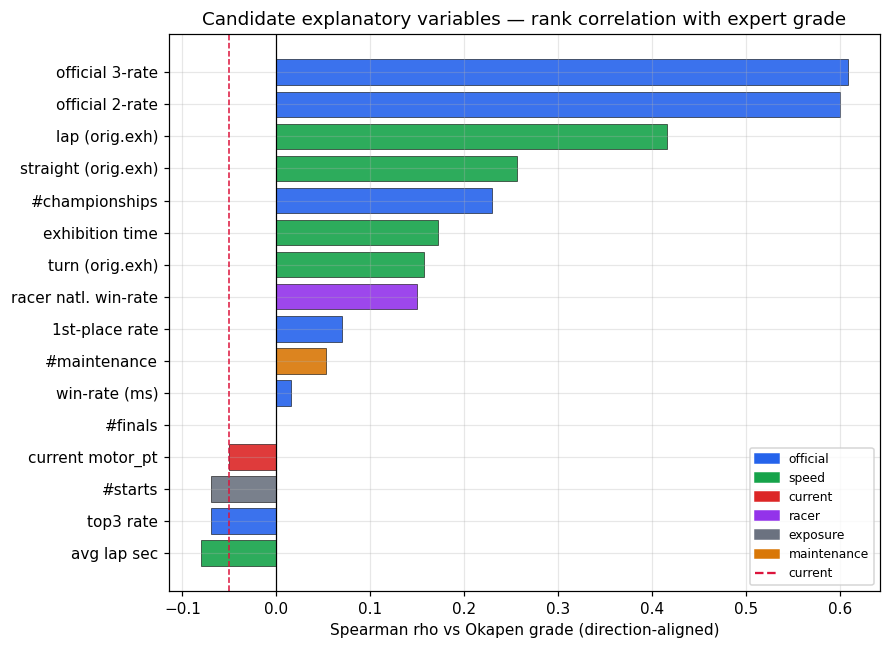

In [6]:
# 候補変数(reference除く)の Spearman を横棒で可視化
romaji = {
    "公式2連対率":"official 2-rate","公式3連対率":"official 3-rate","現モーターpt(現状)":"current motor_pt",
    "選手全国勝率(参考)":"racer natl. win-rate","展示タイム":"exhibition time","一周(周回)":"lap (orig.exh)",
    "まわり足":"turn (orig.exh)","直線":"straight (orig.exh)","勝率(motor_stats)":"win-rate (ms)",
    "平均ラップ秒":"avg lap sec","優勝回数":"#championships","優出回数":"#finals","1着率":"1st-place rate",
    "3着内率":"top3 rate","出走数":"#starts","整備(部品交換)回数":"#maintenance",
}
plot_df = scan[scan["区分"] != "reference"].dropna(subset=["Spearman ρ"]).sort_values("Spearman ρ")
colors = {"official":"#2563eb","speed":"#16a34a","current":"#dc2626","racer":"#9333ea",
          "exposure":"#6b7280","maintenance":"#d97706"}
fig, ax = plt.subplots(figsize=(8.2, 6.0))
ys = range(len(plot_df))
ax.barh(list(ys), plot_df["Spearman ρ"],
        color=[colors.get(k, "#888") for k in plot_df["区分"]], alpha=0.9, edgecolor="k", linewidth=0.4)
ax.set_yticks(list(ys)); ax.set_yticklabels([romaji.get(s, s) for s in plot_df["説明変数(向き補正後)"]])
ax.axvline(0, color="k", lw=0.8)
cur = scan.loc[scan["説明変数(向き補正後)"]=="現モーターpt(現状)", "Spearman ρ"].iloc[0]
ax.axvline(cur, color="crimson", ls="--", lw=1, label=f"current motor_pt = {cur:.2f}")
ax.set_xlabel("Spearman rho vs Okapen grade (direction-aligned)")
ax.set_title("Candidate explanatory variables — rank correlation with expert grade")
from matplotlib.patches import Patch
leg = [Patch(color=c, label=k) for k, c in colors.items()]
ax.legend(handles=leg + [plt.Line2D([0],[0],color="crimson",ls="--",label="current")],
          loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

**読み取り方**
- **公式2連対率/3連対率**(青, daily, 全40機)が最上位なら、まず取り込むべき第一候補。
- **速さ系**(緑, 一周・直線・展示タイム・平均ラップ)が中位に来るなら、エキスパートの
  「出足・伸び」評価を数値で代理でき、追加成分の候補になる。ただし展示・周回足は
  **直前(realtime)でしか取れない** ため、朝バッチのモーターptには使えず、
  「直前モーターpt」など realtime 専用の改良に回す前提。
- **現モーターpt**(赤破線)が 0 付近に留まるなら、現状の着順ベース指標は単独では
  エキスパート評価をほぼ説明できていない、という現状確認になる。

## 5. 改善仮説の検証 — 有望候補を合成したスコアの順位相関

スキャン上位の候補を合成して、おかぺん評価との順位一致を上げられるか試す。
**daily で使える候補のみ** で組む案(本番モーターptへ直結可能)と、
**realtime 候補も足した** 案(直前改良用)を分けて評価する。

In [7]:
def z(s):
    s = pd.to_numeric(s, errors="coerce").astype(float)
    mu, sd = np.nanmean(s), np.nanstd(s)
    return ((s - mu) / (sd if sd > 0 else 1.0)).values

g = df["評価num"].values
Z = pd.DataFrame({
    "cur":   z(df["現モーターpt"]),
    "r2":    z(df["公式2連対率"]),
    "r3":    z(df["公式3連対率"]),
    "exh":   z(-df["展示タイム"]),   # 速い=小 → 反転
    "lap":   z(-df["一周"]),         # 速い=小 → 反転
})

variants = {}
variants["現モーターpt (現状)"]              = Z["cur"].values
variants["公式2連対率のみ"]                  = Z["r2"].values
variants["公式3連対率のみ"]                  = Z["r3"].values
variants["[daily] 現pt+2連対率+3連対率"]      = Z[["cur","r2","r3"]].mean(axis=1).values
variants["[realtime] 上記+展示+一周"]         = Z[["cur","r2","r3","exh","lap"]].mean(axis=1).values

# daily 候補だけでグリッド探索(cur,r2,r3 非負重み・合計1)
best = None
grid = [i/10 for i in range(11)]
for a, b in product(grid, grid):
    c = 1 - a - b
    if c < -1e-9: continue
    bl = a*Z["cur"] + b*Z["r2"] + c*Z["r3"]
    rho = spearmanr(bl, g).correlation
    if best is None or rho > best[0]:
        best = (rho, round(a,1), round(b,1), round(c,1))
variants[f"[daily]最適ブレンド cur={best[1]},r2={best[2]},r3={best[3]}"] = \
    (best[1]*Z["cur"] + best[2]*Z["r2"] + best[3]*Z["r3"]).values

# 線形回帰 + LOO-CV（daily特徴 [cur,r2,r3]）
def loo_cv(Xcols):
    X = Z[Xcols].values
    pred = np.empty(len(g))
    for i in range(len(g)):
        tr = np.arange(len(g)) != i
        pred[i] = LinearRegression().fit(X[tr], g[tr]).predict(X[i:i+1])[0]
    return pred
variants["[daily] 線形回帰 (LOO-CV)"]          = loo_cv(["cur","r2","r3"])
variants["[realtime] 線形回帰+展示+一周 (LOO-CV)"] = loo_cv(["cur","r2","r3","exh","lap"])

rows = [(n, round(rank_corr(v, g)[0],3), round(rank_corr(v, g)[1],3)) for n, v in variants.items()]
res = pd.DataFrame(rows, columns=["候補スコア","Spearman ρ","Kendall τ"]).sort_values("Spearman ρ", ascending=False).reset_index(drop=True)
print("おかぺん評価との順位相関(合成スコア比較):")
display(res)

full = LinearRegression().fit(Z[["cur","r2","r3"]].values, g)
print("\n線形回帰係数(全データfit, daily特徴 [cur,r2,r3], 標準化):")
for name, coef in zip(["cur","r2","r3"], full.coef_):
    print(f"  {name:4s}: {coef:+.3f}")

おかぺん評価との順位相関(合成スコア比較):


,候補スコア,Spearman ρ,Kendall τ
0,"[daily]最適ブレンド cur=0.0,r2=0.6,r3=0.4",0.633,0.474
1,[realtime] 上記+展示+一周,0.617,0.477
2,公式3連対率のみ,0.608,0.439
3,公式2連対率のみ,0.600,0.451
4,[daily] 現pt+2連対率+3連対率,0.554,0.414
5,[daily] 線形回帰 (LOO-CV),0.500,0.354
6,[realtime] 線形回帰+展示+一周 (LOO-CV),0.461,0.338
7,現モーターpt (現状),-0.050,-0.013



線形回帰係数(全データfit, daily特徴 [cur,r2,r3], 標準化):
  cur : +0.118
  r2  : +0.438
  r3  : +1.039


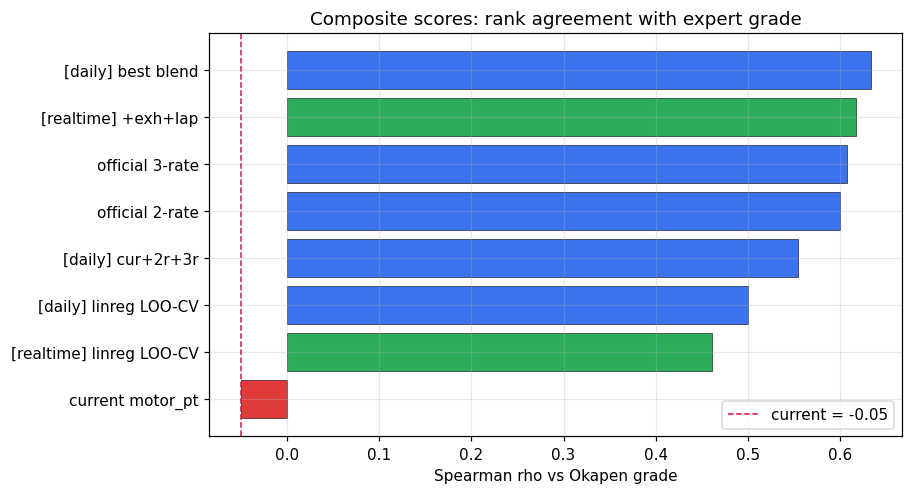

In [8]:
order = res.sort_values("Spearman ρ")
def lab(s):
    if "最適ブレンド" in s: return "[daily] best blend"
    return (s.replace("現モーターpt (現状)","current motor_pt")
             .replace("公式2連対率のみ","official 2-rate").replace("公式3連対率のみ","official 3-rate")
             .replace("[daily] 現pt+2連対率+3連対率","[daily] cur+2r+3r")
             .replace("[realtime] 上記+展示+一周","[realtime] +exh+lap")
             .replace("[daily] 線形回帰 (LOO-CV)","[daily] linreg LOO-CV")
             .replace("[realtime] 線形回帰+展示+一周 (LOO-CV)","[realtime] linreg LOO-CV"))
fig, ax = plt.subplots(figsize=(8.4, 4.6))
ys = range(len(order))
cols = ["#16a34a" if "realtime" in s else ("#dc2626" if "現状" in s else "#2563eb") for s in order["候補スコア"]]
ax.barh(list(ys), order["Spearman ρ"], color=cols, alpha=0.9, edgecolor="k", linewidth=0.4)
ax.set_yticks(list(ys)); ax.set_yticklabels([lab(s) for s in order["候補スコア"]])
cur = res.loc[res["候補スコア"]=="現モーターpt (現状)","Spearman ρ"].iloc[0]
ax.axvline(cur, color="crimson", ls="--", lw=1, label=f"current = {cur:.2f}")
ax.set_xlabel("Spearman rho vs Okapen grade"); ax.set_title("Composite scores: rank agreement with expert grade")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

**読み取り方**
- daily 合成(青)が現状(赤破線)を大きく上回れば、**本番モーターptに今すぐ足せる改善**。
- realtime 合成(緑)がさらに上回れば、**直前モーターptの追加改良** の価値がある。
- `最適ブレンド` は同一データで重みを選ぶため過適合気味。汎化は **LOO-CV** の ρ を重視。

## 6. 結論と次のステップ

**この検証から言えること**(実数は上のセル出力を参照)
- **現モーターptはおかぺん評価をほぼ追えていない**(順位相関がほぼ 0、中立50フォールバックも多い)。
- **説明変数候補の順位**(おかぺん評価との相関の高い順、向き補正後)は §4 のスキャン表のとおり。
  上位は概ね **公式2連対率/3連対率 > 速さ系(一周・直線・展示タイム)> 優勝回数 …** となる。
- daily で全 40 機を覆える **公式2連対率/3連対率** が第一候補。直前限定だが **一周・展示タイム** 等の
  速さ系も追加候補になる。

**モーターptの組成に使える説明変数の候補(まとめ)**
1. **公式2連対率 / 3連対率**(daily・全機)— 最優先。場別偏差値化して成分追加。
2. **速さ系: 一周・直線・展示タイム・平均ラップ**(多くは直前limited)— 直前モーターptの改良候補。
3. **優勝回数・優出回数・1着率**(daily, ただし motor_stats は今節 n=26)— 補助候補。
4. **整備(部品交換)回数・出走数**— 寄与は小さめだが、安定性/サンプル量の調整変数として検討余地。

**限界・注意**
- n≤40・単一場・単一節。相関値は参考値で、場・節をまたいだ再現性は未検証。
- `motor_stats` は本節の平和島分が機番 55〜75 を欠き n=26。speed/優勝回数等の評価はこの制約付き。
- 展示タイム・周回足は **直前(realtime)** でしか取れず、朝バッチのモーターptには使えない。
- `最適ブレンド` は過適合があるため汎化は LOO-CV を主に見る。
- おかぺん評価には整備・乗り手相性など主観情報が含まれ、数値特徴だけでは上限がある。

**次の一手**
- おかぺん評価を **定期スクレイプ&保存** してサンプル拡大(複数場・複数節)。
- `motor_stats` の機番欠落を解消し、速さ系・優勝回数を全機で再評価。
- 本ノートの結合・スキャンを複数場/複数節に一般化して改善幅の安定性を確認。
- 安定して効く候補(まず公式2連対率)を `index_features.py` のモーター成分に組み込み、
  `build_weights.py` で重み再学習(本ノートでは本番コードは変更しない)。
